In [ ]:
#"Klasifikasi Status Kesehatan Janin Berdasarkan Data Kardiotokografi Menggunakan Algoritma Random Forest Classifier",

In [ ]:
# === 1. IMPORT LIBRARY ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Model
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from imblearn.combine import SMOTETomek
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Imbalance handling & Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

print("Library berhasil di-import.")

Library berhasil di-import.


In [ ]:
# === 2. DATA UNDERSTANDING ===
df = pd.read_csv('fetal_health.csv')
df['fetal_health'] = df['fetal_health'].astype(int)
print(f"Jumlah data awal: {df.shape[0]} baris, {df.shape[1]} kolom")
print("\nInformasi Dataset:")
df.info()
print("\nStatistik Deskriptif:")
display(df.describe().T)
print("\nJumlah Missing Value tiap kolom:")
print(df.isnull().sum())

Jumlah data awal: 2126 baris, 22 kolom

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non

,count,mean,std,min,25%,50%,75%,max
baseline value,2126.0,133.303857,9.840844,106.0,126.000,133.000,140.000,160.000
accelerations,2126.0,0.003178,0.003866,0.0,0.000,0.002,0.006,0.019
fetal_movement,2126.0,0.009481,0.046666,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2126.0,0.004366,0.002946,0.0,0.002,0.004,0.007,0.015
light_decelerations,2126.0,0.001889,0.002960,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2126.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2126.0,0.000159,0.000590,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2126.0,46.990122,17.192814,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2126.0,1.332785,0.883241,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2126.0,9.846660,18.396880,0.0,0.000,0.000,11.000,91.000



Jumlah Missing Value tiap kolom:
baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histog

In [ ]:
# === 3. DATA PREPROCESSING ===
# 1. Hapus duplikat
df.drop_duplicates(inplace=True)
print(f"Jumlah data setelah hapus duplikat: {df.shape[0]} baris")

# 2. Pisahkan fitur (X) dan target (y)
X = df.drop('fetal_health', axis=1)
y = df['fetal_health']

# 3. Label adjustment (XGBoost butuh label mulai dari 0, bukan 1)
y_adjusted = y - 1

print("\nPreprocessing selesai: Data bersih & label sudah disesuaikan.")

Jumlah data setelah hapus duplikat: 2113 baris

Preprocessing selesai: Data bersih & label sudah disesuaikan.


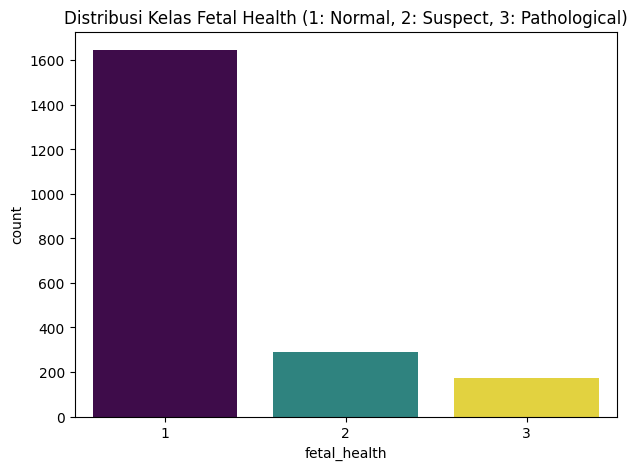

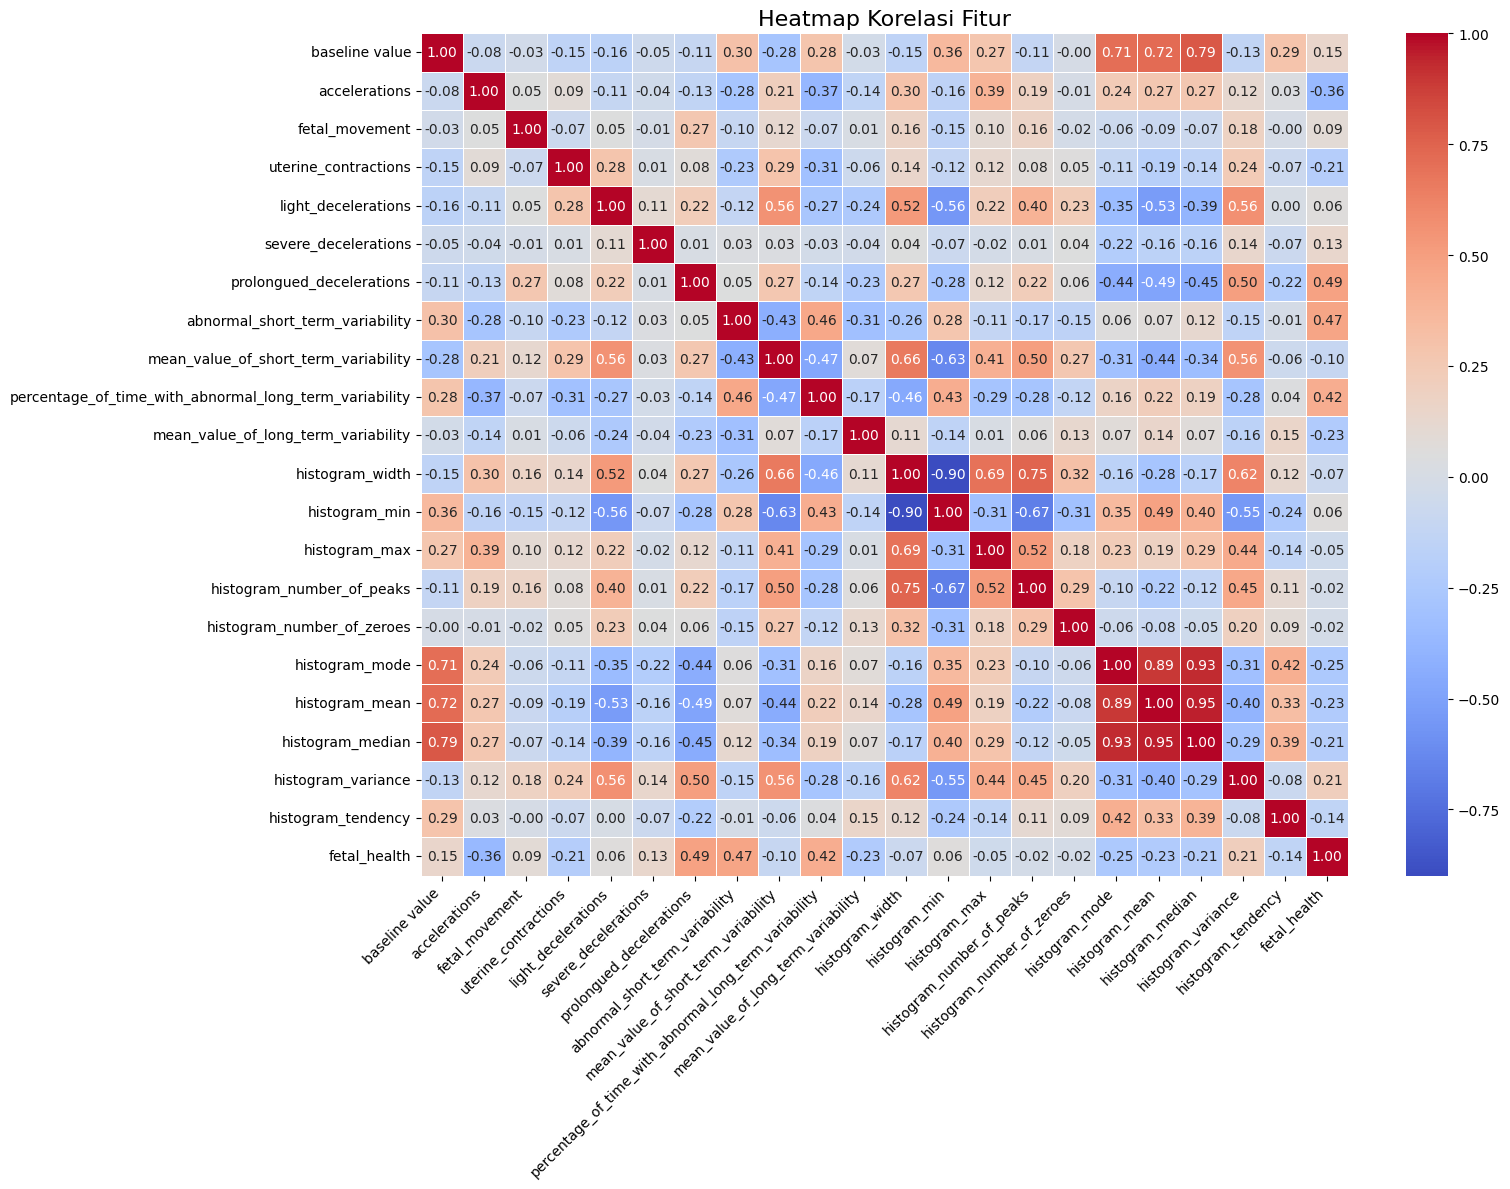

In [ ]:
# === 4. EXPLORATORY DATA ANALYSIS (EDA) ===
# A. Distribusi kelas
plt.figure(figsize=(7,5))
sns.countplot(x=y, hue=y, palette='viridis', legend=False)
plt.title('Distribusi Kelas Fetal Health (1: Normal, 2: Suspect, 3: Pathological)')
plt.show()

# B. Heatmap korelasi

plt.figure(figsize=(16,12)) # Ukuran figure diperbesar
sns.heatmap(df.corr(), cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5) # Mengaktifkan annot dan menambahkan format angka
plt.title('Heatmap Korelasi Fitur', fontsize=16)
plt.xticks(rotation=45, ha='right') # Rotasi label sumbu X
plt.yticks(rotation=0) # Label sumbu Y tetap horizontal
plt.tight_layout() # Agar tidak ada bagian yang terpotong
plt.show()

In [ ]:
# === 5. MODEL & PARAMETER GRID CONFIGURATION ===

from sklearn.model_selection import GridSearchCV

# Definisi Model
models = {
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(
        random_state=42,
        objective='multi:softmax',
        num_class=3,
        eval_metric='mlogloss'
    )
}

# Parameter Tuning
param_grid = {
    'KNN': {
        'model__n_neighbors': [3, 5, 7],
        'model__weights': ['uniform', 'distance']
    },

    'Random Forest': {
        'model__n_estimators': [50, 100],
        'model__max_depth': [5, 10],
        'model__min_samples_split': [2, 5],
        'model__min_samples_leaf': [1, 3]
    },

    'XGBoost': {
        'model__n_estimators': [50, 100],
        'model__max_depth': [3],
        'model__learning_rate': [0.01],
        'model__subsample': [0.8, 1],
        'model__colsample_bytree': [0.8]
    }
}

# Variasi Split Data
splits = {
    '70:30': 0.3,
    '80:20': 0.2,
    '90:10': 0.1
}

print("Konfigurasi model & parameter siap.")

Konfigurasi model & parameter siap.


In [ ]:
# === 6. TRAINING, TUNING & EVALUATION ===
hasil_evaluasi = []
hasil_prediksi = {}
best_models = {}

from sklearn.model_selection import StratifiedKFold

# Stratified K-Fold (lebih stabil & seimbang)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f" SEDANG MENGOPTIMALKAN MODEL: {model_name} ")
    print("="*60)

    hasil_prediksi[model_name] = {}

    for split_name, test_size in splits.items():

        # 1. Splitting
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_adjusted,
            test_size=test_size,
            random_state=42,
            stratify=y_adjusted
        )

        # 2. Pipeline (SMOTE hanya di training fold via CV)
        # NOTE: scaler hanya penting untuk KNN, tapi kita keep biar konsisten
        pipeline = ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote', SMOTETomek(random_state=42)),
            ('model', model)
        ])

        # 3. GridSearchCV (pakai StratifiedKFold)
        grid = GridSearchCV(
            pipeline,
            param_grid[model_name],
            cv=cv,
            scoring='f1_macro',
            n_jobs=-1,
            error_score='raise'
        )

        # 4. Training
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        best_models[(model_name, split_name)] = best_model

        # 5. Prediksi
        y_pred = best_model.predict(X_test)

        # 6. Evaluasi
        acc = accuracy_score(y_test, y_pred)
        hasil_evaluasi.append([model_name, split_name, acc])
        hasil_prediksi[model_name][split_name] = (y_test, y_pred)

        print(f"\n[Split {split_name}]")
        print(f"Best Params: {grid.best_params_}")
        print(f"Accuracy   : {acc:.4f}")
        print(classification_report(
            y_test, y_pred,
            target_names=['Normal', 'Suspect', 'Pathological']
        ))


 SEDANG MENGOPTIMALKAN MODEL: KNN 

[Split 70:30]
Best Params: {'model__n_neighbors': 7, 'model__weights': 'distance'}
Accuracy   : 0.8675
              precision    recall  f1-score   support

      Normal       0.98      0.88      0.93       494
     Suspect       0.53      0.80      0.63        88
Pathological       0.81      0.88      0.84        52

    accuracy                           0.87       634
   macro avg       0.77      0.85      0.80       634
weighted avg       0.90      0.87      0.88       634


[Split 80:20]
Best Params: {'model__n_neighbors': 7, 'model__weights': 'distance'}
Accuracy   : 0.8794
              precision    recall  f1-score   support

      Normal       0.98      0.89      0.93       330
     Suspect       0.55      0.83      0.66        58
Pathological       0.83      0.86      0.85        35

    accuracy                           0.88       423
   macro avg       0.79      0.86      0.81       423
weighted avg       0.91      0.88      0.89      

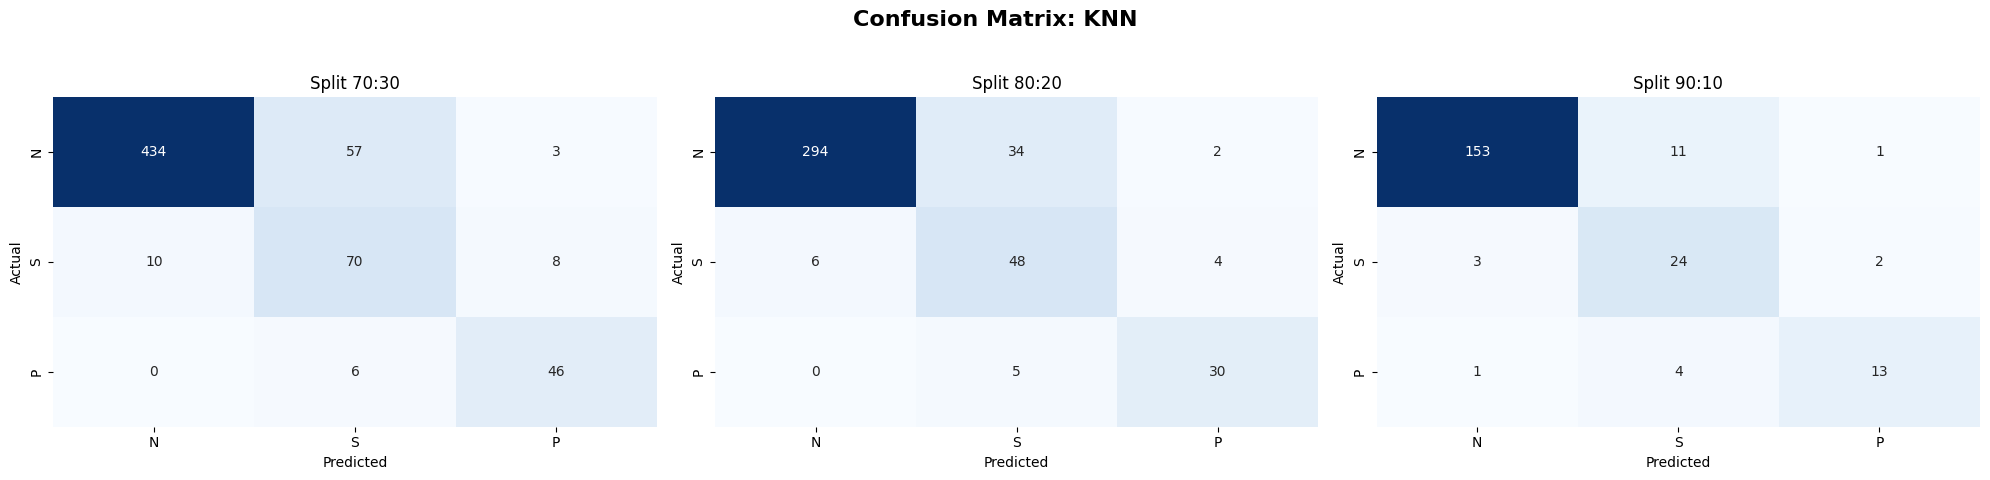

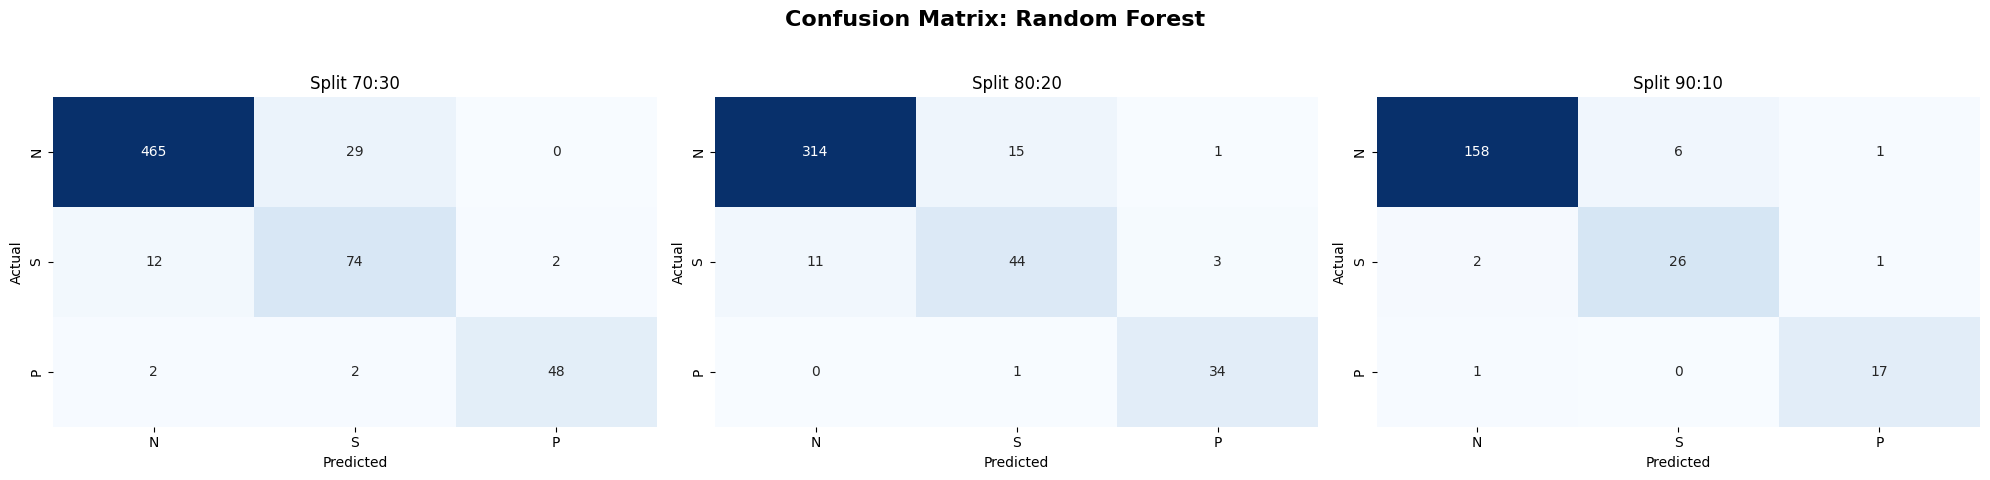

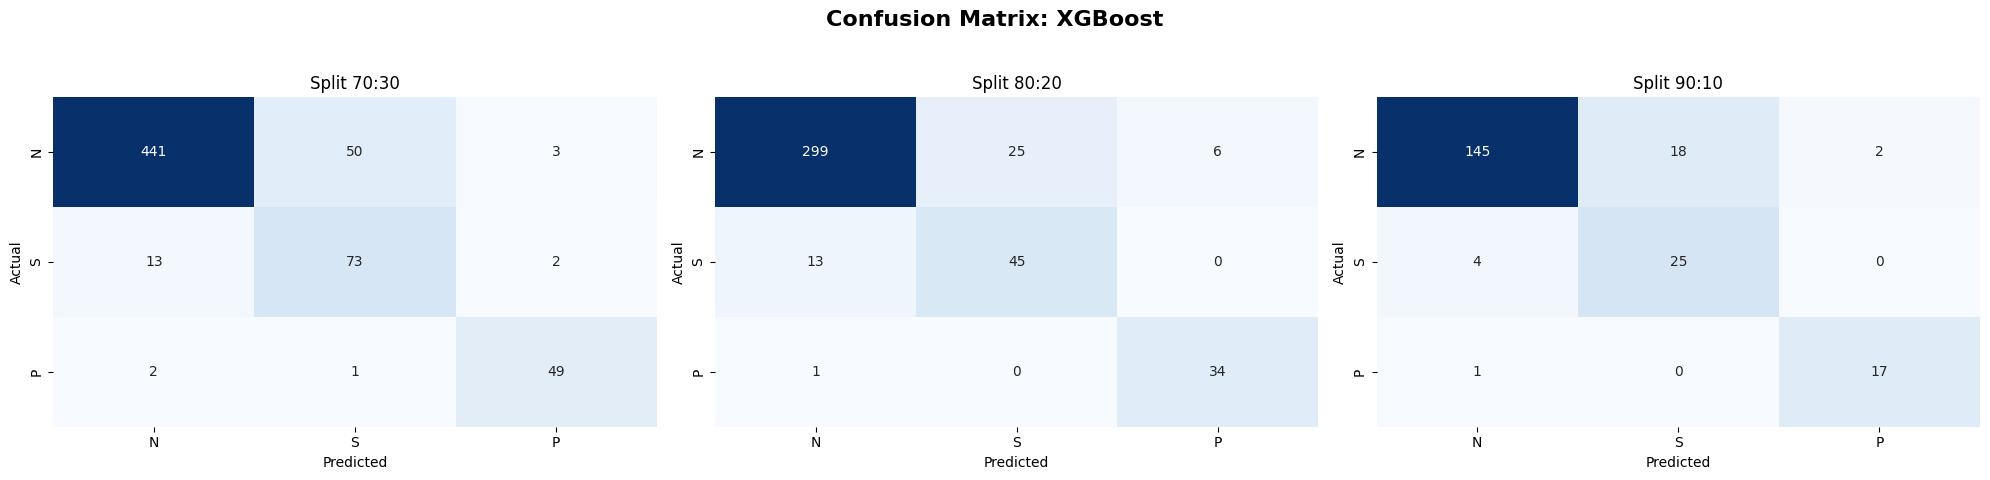

In [ ]:
# === 7. CONFUSION MATRIX VISUALIZATION ===
for model_name in models.keys():
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f'Confusion Matrix: {model_name}', fontsize=16, fontweight='bold')

    for i, split_name in enumerate(splits.keys()):
        y_test, y_pred = hasil_prediksi[model_name][split_name]
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
        axes[i].set_title(f'Split {split_name}')
        axes[i].set_xticklabels(['N', 'S', 'P']); axes[i].set_yticklabels(['N', 'S', 'P'])
        axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('Actual')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


Tabel Perbandingan Akurasi:


Split,70:30,80:20,90:10
Algoritma,,,
KNN,0.867508,0.879433,0.896226
Random Forest,0.925868,0.926714,0.948113
XGBoost,0.888013,0.893617,0.882075


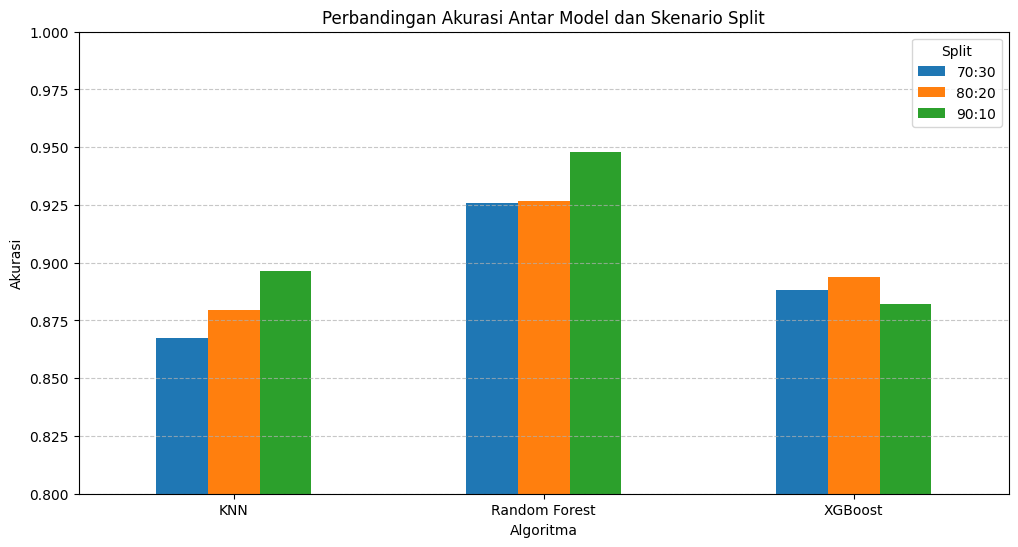

In [ ]:
# === 8. MODEL COMPARISON ===
df_hasil = pd.DataFrame(hasil_evaluasi, columns=['Algoritma', 'Split', 'Accuracy'])
tabel = df_hasil.pivot(index='Algoritma', columns='Split', values='Accuracy')

print("\nTabel Perbandingan Akurasi:")
display(tabel)

tabel.plot(kind='bar', figsize=(12,6))
plt.title('Perbandingan Akurasi Antar Model dan Skenario Split')
plt.ylabel('Akurasi')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:

# ===  BEST MODEL SELECTION ===

df_hasil = pd.DataFrame(hasil_evaluasi, columns=['Model','Split','Accuracy'])

best = df_hasil.loc[df_hasil['Accuracy'].idxmax()]

print("=== BEST MODEL ===")
print(best)

best_model_name = best['Model']
best_split = best['Split']

print(f"\nModel Terbaik : {best_model_name}")
print(f"Split Terbaik : {best_split}")

# ambil model terbaik
model_terbaik = best_models[(best_model_name, best_split)]

import joblib

filename = f"model_{best_model_name.replace(' ', '_')}.pkl"
joblib.dump(model_terbaik, filename)

print(f"\nModel berhasil disimpan sebagai: {filename}")

=== BEST MODEL ===
Model       Random Forest
Split               90:10
Accuracy         0.948113
Name: 5, dtype: object

Model Terbaik : Random Forest
Split Terbaik : 90:10

Model berhasil disimpan sebagai: model_Random_Forest.pkl


In [ ]:
# === 10. INFERENCE ===

import pandas as pd

# input file (boleh kosong)
file_path = input("Masukkan nama file CSV (kosongkan untuk pakai data internal): ").strip()

# pakai OR (tanpa if)
new_df = (file_path and pd.read_csv(file_path)) or X.iloc[:5]

# samakan kolom
new_df = new_df.reindex(columns=X.columns).fillna(0)

print("\n Data input:")
display(new_df)

# prediksi
hasil = model_terbaik.predict(new_df)

# mapping label
label_map = {
    0: "Normal",
    1: "Suspect",
    2: "Pathological"
}

print("\n Hasil Prediksi:")
for i, h in enumerate(hasil):
    print(f"Data ke-{i+1}: {label_map[h]}")

# tampilkan versi angka (sekali saja)
print("\nHasil Prediksi (angka):", hasil)

# pembanding (hanya valid kalau pakai data internal)
print("Label Asli:", y_adjusted.iloc[:len(hasil)].values)

Masukkan nama file CSV (kosongkan untuk pakai data internal): 

 Data input:


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0



 Hasil Prediksi:
Data ke-1: Suspect
Data ke-2: Normal
Data ke-3: Normal
Data ke-4: Normal
Data ke-5: Normal

Hasil Prediksi (angka): [1 0 0 0 0]
Label Asli: [1 0 0 0 0]


In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold

print("=== ANALISIS STABILITAS MODEL (5-FOLD CROSS VALIDATION) ===")

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in models.items():

    pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y_adjusted,
        cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'f1': 'f1_macro'
        },
        n_jobs=-1
    )

    print(f"\nModel: {name}")
    print(f"Mean Accuracy : {scores['test_accuracy'].mean():.4f}")
    print(f"Std Accuracy  : {scores['test_accuracy'].std():.4f}")

    print(f"Mean F1 Macro : {scores['test_f1'].mean():.4f}")
    print(f"Std F1 Macro  : {scores['test_f1'].std():.4f}")

=== ANALISIS STABILITAS MODEL (5-FOLD CROSS VALIDATION) ===

Model: KNN
Mean Accuracy : 0.8784
Std Accuracy  : 0.0036
Mean F1 Macro : 0.8084
Std F1 Macro  : 0.0068

Model: Random Forest
Mean Accuracy : 0.9347
Std Accuracy  : 0.0052
Mean F1 Macro : 0.8848
Std F1 Macro  : 0.0100

Model: XGBoost
Mean Accuracy : 0.9446
Std Accuracy  : 0.0076
Mean F1 Macro : 0.9010
Std F1 Macro  : 0.0121


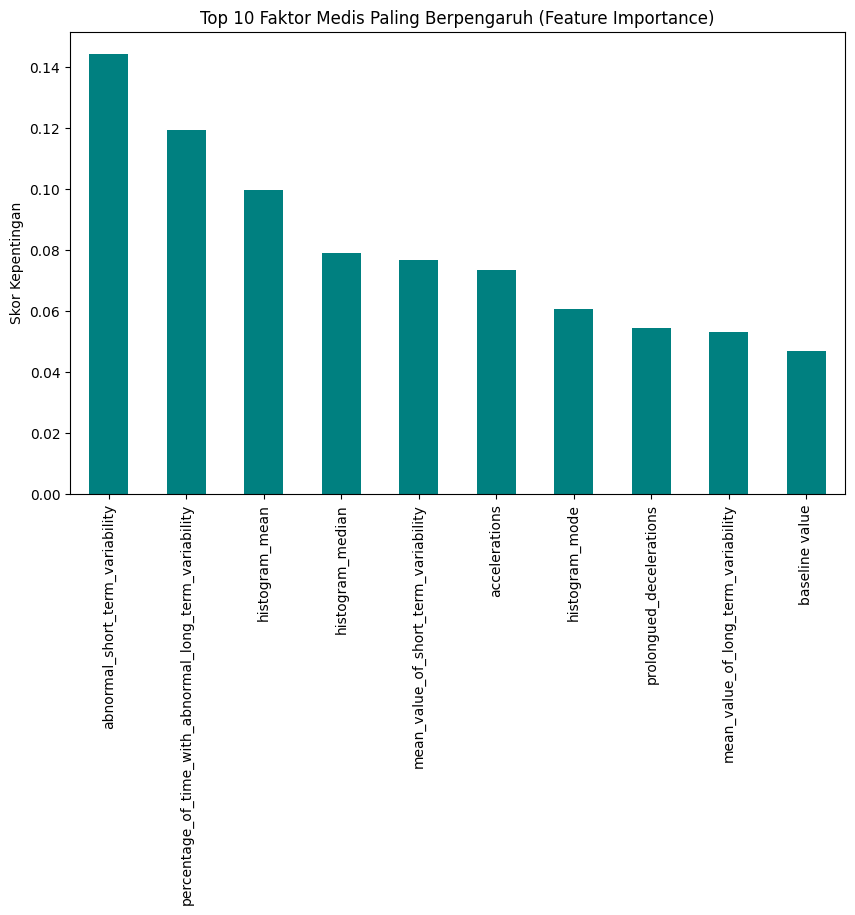

In [ ]:
# === 10. FEATURE IMPORTANCE (RANDOM FOREST) ===
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
pipeline_rf = ImbPipeline([('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)), ('model', model_rf)])
X_train, X_test, y_train, y_test = train_test_split(
    X, y_adjusted, test_size=0.2, stratify=y_adjusted, random_state=42
)

pipeline_rf.fit(X_train, y_train)

importances = pipeline_rf.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Faktor Medis Paling Berpengaruh (Feature Importance)')
plt.ylabel('Skor Kepentingan')
plt.show()